In [1]:
!pip install netcdf4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from netCDF4 import Dataset as NetCDFFile
import random 
import timeit
import pickle
from scipy import stats
import time


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
# using RK4 to derive the data for training 
# function to be solved
def f(y):
    return y-np.power(y,3)

# or
# f = lambda x: x+y

# RK-4 method
def rk4(x0,y0,xn,n):
    
    # Calculating step size
    h = (xn-x0)/n
    
    print('\n--------SOLUTION--------')
    print('-------------------------')    
    print('x0\ty0\tyn')
    print('-------------------------')
    for i in range(n+1):
        k1 = h * (f(y0))
        k2 = h * (f((y0+k1/2)))
        k3 = h * (f((y0+k2/2)))
        k4 = h * (f((y0+k3)))
        k = (k1+2*k2+2*k3+k4)/6
        yn = y0 + k
        #print('%.4f\t%.4f\t%.4f'% (x0,y0,yn) )
        #print('-------------------------')
        y0 = yn
        x0 = x0+h
    return yn
    #print('\nAt x=%.4f, y=%.4f' %(xn,yn))

In [3]:
# using RK4 to generate ground truth 
# Inputs
print('Enter initial conditions:')
t0 = 0
x0_RK4 = np.arange(-2,2.01,0.01)

print('Enter calculation point: ')
tn = 0.2

print('Enter number of steps:')
step = 1000

x_RK4  = np.zeros((100,np.size(x0_RK4)))
x_RK4[0,:] = x0_RK4
# RK4 method call
for i in range(100-1):
    x_RK4[i+1,:] = rk4(t0,x0_RK4,tn,step)
    x0_RK4     = x_RK4[i+1,:]

Enter initial conditions:
Enter calculation point: 
Enter number of steps:

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	y0	yn
-------------------------

--------SOLUTION--------
-------------------------
x0	

Text(0, 0.5, 'Final position')

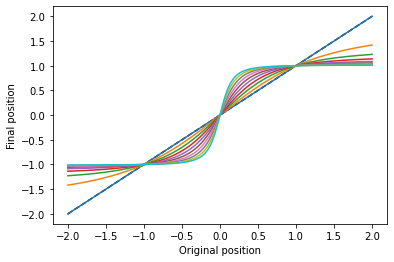

In [4]:
x_ref  = np.arange(-2,2.01,0.01)
plt.figure()
plt.plot(x_ref,x_ref,'k--')
for i in range(10):
    plt.plot(x_ref,x_RK4[i,:])
plt.xlabel('Original position')
plt.ylabel('Final position')

In [5]:
# generate Gaussian distribution
def PDF(x,mu,std):
    return stats.norm(mu, std).pdf(x)
x    = np.arange(-2,2.01,0.01)
rho  = PDF(x,0.05,0.05)